In [1]:
import gymnasium as gym

from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from stable_baselines3.common.evaluation import evaluate_policy

from pprint import pprint
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

np.set_printoptions(suppress=True)

In [2]:
ROLL_NUMBER = "DA25M622"

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print("Assigned configuration generated successfully.")
for key, value in config_summary.items():
    print(f"{key}: {value}")

Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25M622
variant_id: V022
config_fingerprint: 7d77fc79debf206a
demand_multiplier_profile: [1.0, 1.1, 0.9]
initial_inventory_profile: [110, 100, 90]
lead_time_delay_profile: [0.1, 0.0, 0.05]


In [3]:
env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

observation, info = env.reset(seed=2026)

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
pprint(info)

Action space: MultiDiscrete([11 11 11])
Observation space: Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32))
{'config_fingerprint': '7d77fc79debf206a',
 'episode_parameters': {'delay_probabilities': [0.08, 0.0, 0.05],
                        'demand_multipliers': [1.05, 1.05, 0.85],
                        'initial_inventory': [110, 100, 90],
                        'scenario_components': ['seasonal', 'trend'],
                        'scenario_details': {'seasonal_amplitudes': [0.06241472342761341,
                                                                     0.09569493618795924,
                                                                     0.07088119371488985],
                                             'trend_direction': 'up',
                                             'trend_total_change'

In [4]:
from functools import partial
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor

env_fn = lambda: IndustrialInventoryEnv(student_config=student_config, scenario_mode="random", domain_randomization=True)

# Parallelize across 4 environments
vec_env = make_vec_env(
    env_id=env_fn,
    n_envs=4,
    seed=2026,
    # vec_env_cls=SubprocVecEnv,        # TODO: Use SubprocVecEnv for true multiprocessing; or default DummyVecEnv if debugging
)
vec_env = VecMonitor(vec_env)
vec_env

/home/sohang/Projects/iit-madras-web-mtech-ai/trimester3/DA6002W_Online&ReinforcementLearning/ReinforcementLearning/RL_ProjectCompetition/RL_Student_Package_2026/.venv-sb3-torch213/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


In [5]:
# use "MultiInputPolicy" for environments with Dict observation spaces
model = A2C("MultiInputPolicy", vec_env, verbose=1)
model.learn(total_timesteps=25000)
model.save("a2c_industrial_inventory")

Using cpu device
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 50        |
|    ep_rew_mean        | -6.03e+03 |
| time/                 |           |
|    fps                | 1334      |
|    iterations         | 100       |
|    time_elapsed       | 1         |
|    total_timesteps    | 2000      |
| train/                |           |
|    entropy_loss       | -6.34     |
|    explained_variance | -2.55e-05 |
|    learning_rate      | 0.0007    |
|    n_updates          | 99        |
|    policy_loss        | -1.86e+03 |
|    value_loss         | 1.32e+05  |
-------------------------------------
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 50        |
|    ep_rew_mean        | -4.93e+03 |
| time/                 |           |
|    fps                | 1214      |
|    iterations         | 200       |
|    time_elapsed       | 3         |
|    total_timesteps    | 4000   

In [7]:
loaded_model = A2C.load("a2c_industrial_inventory.zip")

In [8]:
# manual eval loop for 1 episode, to get the info dict for each step, to get the costs
records = []
observation, info = env.reset(seed=101)
while True:
    action, _ = loaded_model.predict(observation, deterministic=True)  # MultiDiscrete indices directly
    observation, reward, terminated, truncated, info = env.step(action)
    records.append({
        "action": action,
        "reward": reward,
        "truncated": truncated,
        "info": info,
        'day': info['day'],
        **info['costs']
    })
    if terminated or truncated:
        break

df = pd.DataFrame(records)
df

,action,reward,truncated,info,day,holding,stockout,ordering,discarding,daily_total,episode_total
0,"[4, 4, 3]",-28.250,False,"{'day': 0, 'demand': [25, 21, 28], 'fulfilled_...",0,2425.0,0.0,400.0,0.0,2825.0,2825.0
1,"[4, 4, 3]",-22.800,False,"{'day': 1, 'demand': [23, 19, 34], 'fulfilled_...",1,1880.0,0.0,400.0,0.0,2280.0,5105.0
2,"[4, 4, 3]",-18.900,False,"{'day': 2, 'demand': [33, 30, 28], 'fulfilled_...",2,1490.0,0.0,400.0,0.0,1890.0,6995.0
3,"[4, 4, 3]",-49.100,False,"{'day': 3, 'demand': [36, 26, 20], 'fulfilled_...",3,1710.0,2800.0,400.0,0.0,4910.0,11905.0
4,"[4, 4, 3]",-29.350,False,"{'day': 4, 'demand': [23, 21, 34], 'fulfilled_...",4,2535.0,0.0,400.0,0.0,2935.0,14840.0
5,"[4, 4, 3]",-29.675,False,"{'day': 5, 'demand': [27, 43, 37], 'fulfilled_...",5,2567.5,0.0,400.0,0.0,2967.5,17807.5
6,"[4, 4, 3]",-32.900,False,"{'day': 6, 'demand': [19, 30, 35], 'fulfilled_...",6,2890.0,0.0,400.0,0.0,3290.0,21097.5
7,"[4, 4, 3]",-34.775,False,"{'day': 7, 'demand': [25, 35, 35], 'fulfilled_...",7,3077.5,0.0,400.0,0.0,3477.5,24575.0
8,"[4, 4, 3]",-38.550,False,"{'day': 8, 'demand': [33, 24, 21], 'fulfilled_...",8,3455.0,0.0,400.0,0.0,3855.0,28430.0
9,"[4, 4, 3]",-41.375,False,"{'day': 9, 'demand': [29, 30, 27], 'fulfilled_...",9,3737.5,0.0,400.0,0.0,4137.5,32567.5


<Axes: >

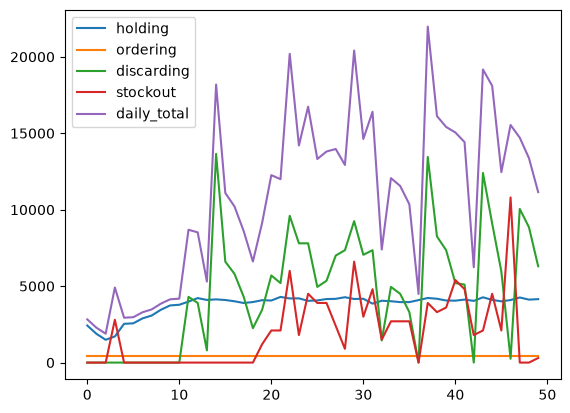

In [11]:
df[['holding', 'ordering', 'discarding', 'stockout', 'daily_total']].plot()      # , 'episode_total'